In this task, three sets of near H-field are provided. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, RationalQuadratic, Matern, ConstantKernel
from sklearn.metrics import mean_absolute_error
from scipy.interpolate import griddata

In [2]:
# Preprocessing of Data
Hfield_data = pd.read_csv('Hxy_mag_e3.txt', sep="  ", engine="python")	# select file with measured values (Hxy_mag_*)
sampling_points = pd.read_csv('sampling_points_e3.txt', sep="\t")			# select according coordinates file (sampling_points_*)

sampling_points.drop(columns=["2"], inplace=True)
X = sampling_points.copy()
y = pd.DataFrame(data=np.sqrt(Hfield_data["0"] ** 2 + Hfield_data["1"] ** 2))


dist = 3.0                              # distance between training points in mm (only granulation of 0.5mm is possible)
x_anchor = 16.5                         # x-value of point that selects where the grid will be (0.5mm granularity)
y_anchor = 16.0                         # y-value of point that selects where the grid will be (0.5mm granularity)

x_low = x_anchor
while x_low >= dist:
    x_low -= dist

x_high = x_anchor
while x_high <= (X.iloc[:, 0].max() - dist):
    x_high += dist

y_low = y_anchor
while y_low >= dist:
    y_low -= dist

y_high = y_anchor
while y_high <= (X.iloc[:, 1].max() - dist):
    y_high += dist

w = []
for i in range(0, len(X)):
    if X.iloc[i, 0] < x_low or X.iloc[i, 0] > x_high or X.iloc[i, 1] < y_low or X.iloc[i, 1] > y_high:
        w.append(i)

v = []
for i in range(0, len(X)):
    if (X.iloc[i, 0] - x_low) % dist == 0 and (X.iloc[i, 1] - y_low) % dist == 0:
        v.append(i)


X_train = X.loc[v]
y_train = y.loc[v]

X.drop(w, inplace=True)
y.drop(w, inplace=True)

In [3]:
# Prediction GPR
kernel = RBF(length_scale=1)                            # kernel can be changed or multiplied/added with other kernels
model = GaussianProcessRegressor(kernel=kernel)         # some kernels are already included (line 5)

model.fit(X_train, y_train - 0)
prediction = model.predict(X)
prediction = prediction + 0

print()
print(
    f"Kernel parameters before fit:\n{kernel} \n"
    f"Log-likelihood: {model.log_marginal_likelihood(kernel.theta):.3f}"
)
print()
print(
    f"Kernel parameters after fit: \n{model.kernel_} \n"
    f"Log-likelihood: {model.log_marginal_likelihood(model.kernel_.theta):.3f}"
)


Kernel parameters before fit:
RBF(length_scale=1) 
Log-likelihood: -506.498

Kernel parameters after fit: 
RBF(length_scale=3.87) 
Log-likelihood: 145.461


In [4]:
# Prediction nearest, linear and cubic Interpolation
x = X_train["0"].to_numpy()
x = np.reshape(x, (len(x),))
Y = X_train["1"].to_numpy()
Y = np.reshape(Y, (len(x),))
z = y_train.to_numpy()
z = np.reshape(z, (len(x),))

Xnew = X["0"].to_numpy()
Xnew = np.reshape(Xnew, (len(Xnew),))
ynew = X["1"].to_numpy()
ynew = np.reshape(ynew, (len(ynew),))

Z1 = griddata((x, Y), z, (Xnew, ynew), method="nearest", fill_value=0.001)
Z2 = griddata((x, Y), z, (Xnew, ynew), method="linear", fill_value=0.001)
Z3 = griddata((x, Y), z, (Xnew, ynew), method="cubic", fill_value=0.001)

Z1 = np.reshape(Z1, (len(Xnew),))
Z2 = np.reshape(Z2, (len(Xnew),))
Z3 = np.reshape(Z3, (len(Xnew),))

print()
print("Prediction with GPR:\t\t\t\t\tMAE=" + str(mean_absolute_error(y, prediction) * len(Xnew) / (len(Xnew)-len(x))))
print("Prediction with nearest Interpolation:\tMAE=" + str(mean_absolute_error(y, Z1) * len(Xnew) / (len(Xnew)-len(x))))
print("Prediction with linear Interpolation:\tMAE=" + str(mean_absolute_error(y, Z2) * len(Xnew) / (len(Xnew)-len(x))))
print("Prediction with cubic Interpolation:\tMAE=" + str(mean_absolute_error(y, Z3) * len(Xnew) / (len(Xnew)-len(x))))
print()
print("Training points: " + str(len(x)))
print("x from " + str(x_low) + "mm to " + str(x_high) + "mm    (x_max = " + str(sampling_points.iloc[:, 0].max()) + "mm)")
print("y from " + str(y_low) + "mm to " + str(y_high) + "mm    (y_max = " + str(sampling_points.iloc[:, 1].max()) + "mm)")


Prediction with GPR:					MAE=0.03588185740745299
Prediction with nearest Interpolation:	MAE=0.045346900051668006
Prediction with linear Interpolation:	MAE=0.038080786295204
Prediction with cubic Interpolation:	MAE=0.03765647905272714

Training points: 529
x from 1.5mm to 67.5mm    (x_max = 69.5mm)
y from 1.0mm to 67.0mm    (y_max = 69.5mm)


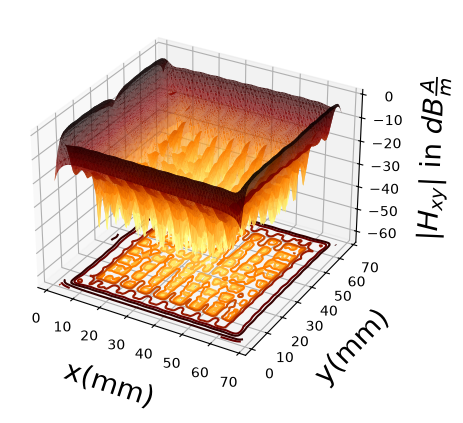

In [5]:
# ----------------------------------------------------------------------------------------------------------------------
# Plotting
# ----------------------------------------------------------------------------------------------------------------------


# Original Plot
y = 20 * np.log10(y)
fig = plt.figure("Original Plot")
ax1 = fig.add_subplot(111, projection='3d')
ax1.plot_trisurf(X["0"], X["1"], y[0], cmap="afmhot_r", linewidth=0, alpha=0.9)
ax1.tricontour(X["0"], X["1"], y[0], 10, cmap="afmhot_r", linestyles="solid", offset=-65)
plt.xlabel(r"x(mm)", fontsize=20, labelpad=12)
plt.ylabel(r"y(mm)", fontsize=20, labelpad=12)
ax1.set_zlabel(r"$|H_{xy}|$ in $dB\frac{A}{m}$", fontsize=20, labelpad=12)
ax1.set_zlim(-65, 2)
plt.show()

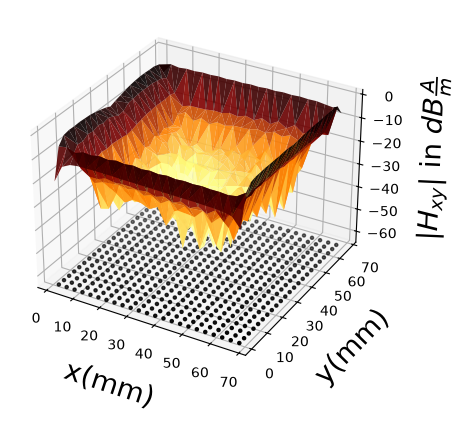

In [6]:
# Measured Plot
y_train = 20 * np.log10(y_train)
fig = plt.figure("Measured Plot")
ax1 = fig.add_subplot(111, projection='3d')
ax1.plot_trisurf(X_train["0"], X_train["1"], y_train[0], cmap="afmhot_r", linewidth=0, alpha=0.9)
ax1.scatter(X_train["0"], X_train["1"], y_train[0] * 0 - 65, s=5, c="black")
plt.xlabel(r"x(mm)", fontsize=20, labelpad=12)
plt.ylabel(r"y(mm)", fontsize=20, labelpad=12)
ax1.set_zlabel(r"$|H_{xy}|$ in $dB\frac{A}{m}$", fontsize=20, labelpad=12)
ax1.set_zlim(-65, 2)
plt.show()

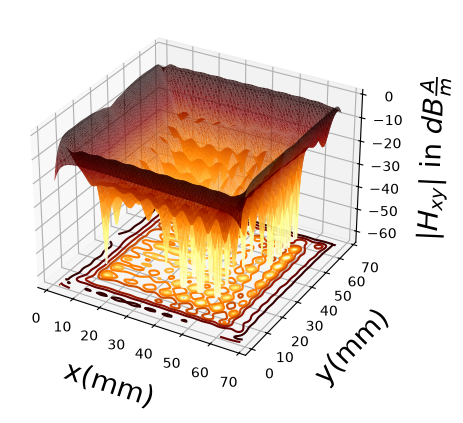

In [7]:
# GPR Predicted Plot
prediction[prediction < 0.001] = 0.001
prediction = 20 * np.log10(prediction)
prediction = np.reshape(prediction, (len(prediction),))
fig = plt.figure("GPR Predicted Plot")
ax1 = fig.add_subplot(111, projection='3d')
ax1.plot_trisurf(X["0"], X["1"], prediction, cmap="afmhot_r", linewidth=0, alpha=0.9)
ax1.tricontour(X["0"], X["1"], prediction, 10, cmap="afmhot_r", linestyles="solid", offset=-65)
plt.xlabel(r"x(mm)", fontsize=20, labelpad=12)
plt.ylabel(r"y(mm)", fontsize=20, labelpad=12)
ax1.set_zlabel(r"$|H_{xy}|$ in $dB\frac{A}{m}$", fontsize=20, labelpad=12)
ax1.set_zlim(-65, 2)
plt.show()

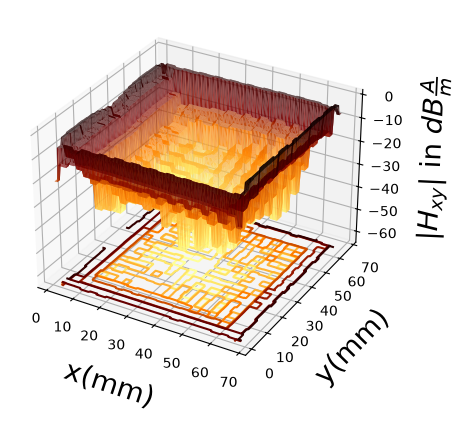

In [8]:
# Nearest Interpolation Plot
Z1 = 20 * np.log10(Z1)
fig = plt.figure("Nearest Interpolation Plot")
ax1 = fig.add_subplot(111, projection='3d')
ax1.plot_trisurf(X["0"], X["1"], Z1, cmap="afmhot_r", linewidth=0, alpha=0.9)
ax1.tricontour(X["0"], X["1"], Z1, 10, cmap="afmhot_r", linestyles="solid", offset=-65)
plt.xlabel(r"x(mm)", fontsize=20, labelpad=12)
plt.ylabel(r"y(mm)", fontsize=20, labelpad=12)
ax1.set_zlabel(r"$|H_{xy}|$ in $dB\frac{A}{m}$", fontsize=20, labelpad=12)
ax1.set_zlim(-65, 2)
plt.show()

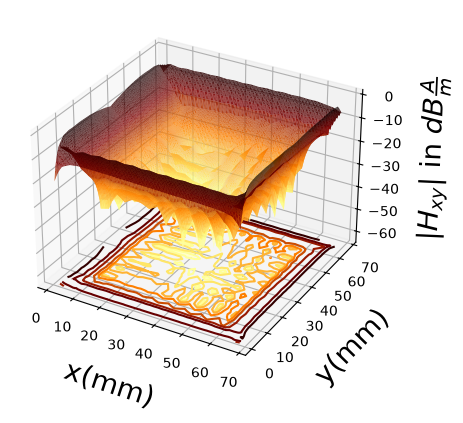

In [9]:
# Linear Interpolation Plot
Z2 = 20 * np.log10(Z2)
fig = plt.figure("Linear Interpolation Plot")
ax1 = fig.add_subplot(111, projection='3d')
ax1.plot_trisurf(X["0"], X["1"], Z2, cmap="afmhot_r", linewidth=0, alpha=0.9)
ax1.tricontour(X["0"], X["1"], Z2, 10, cmap="afmhot_r", linestyles="solid", offset=-65)
plt.xlabel(r"x(mm)", fontsize=20, labelpad=12)
plt.ylabel(r"y(mm)", fontsize=20, labelpad=12)
ax1.set_zlabel(r"$|H_{xy}|$ in $dB\frac{A}{m}$", fontsize=20, labelpad=12)
ax1.set_zlim(-65, 2)
plt.show()

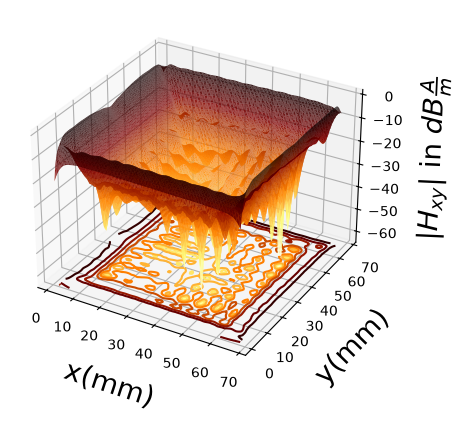

In [10]:
# Cubic Interpolation Plot
Z3[Z3 < 0.001] = 0.001
Z3 = 20 * np.log10(Z3)
fig = plt.figure("Cubic Interpolation Plot")
ax1 = fig.add_subplot(111, projection='3d')
ax1.plot_trisurf(X["0"], X["1"], Z3, cmap="afmhot_r", linewidth=0, alpha=0.9)
ax1.tricontour(X["0"], X["1"], Z3, 10, cmap="afmhot_r", linestyles="solid", offset=-65)
plt.xlabel(r"x(mm)", fontsize=20, labelpad=12)
plt.ylabel(r"y(mm)", fontsize=20, labelpad=12)
ax1.set_zlabel(r"$|H_{xy}|$ in $dB\frac{A}{m}$", fontsize=20, labelpad=12)
ax1.set_zlim(-65, 2)
plt.show()

## MAE comparison for Hxy magnitude E1 and E2

The following cell applies the same 3 mm training grid to Hxy_mag_e1.txt and Hxy_mag_e2.txt, paired with sampling_points_e1.txt and sampling_points_e2.txt. MAE is evaluated only at points that were not used for training, so the four reconstruction methods are compared on unseen samples.


In [11]:
def calculate_reconstruction_mae(dataset, dist=3.0, x_anchor=16.5, y_anchor=16.0):
    """Calculate held-out MAE for GPR and three interpolation methods."""
    hfield_data = pd.read_csv(f"Hxy_mag_{dataset}.txt", sep=r"\s+", engine="python")
    sampling_points = pd.read_csv(f"sampling_points_{dataset}.txt", sep="\t")

    coordinates = sampling_points.drop(columns=["2"]).copy()
    magnitude = np.sqrt(hfield_data["0"] ** 2 + hfield_data["1"] ** 2).to_numpy()

    x_low = x_anchor
    while x_low >= dist:
        x_low -= dist
    x_high = x_anchor
    while x_high <= coordinates.iloc[:, 0].max() - dist:
        x_high += dist

    y_low = y_anchor
    while y_low >= dist:
        y_low -= dist
    y_high = y_anchor
    while y_high <= coordinates.iloc[:, 1].max() - dist:
        y_high += dist

    inside = (
        coordinates.iloc[:, 0].between(x_low, x_high)
        & coordinates.iloc[:, 1].between(y_low, y_high)
    )
    coordinates = coordinates.loc[inside].copy()
    magnitude = magnitude[inside.to_numpy()]

    training_mask = np.asarray(
        np.isclose((coordinates.iloc[:, 0] - x_low) % dist, 0)
        & np.isclose((coordinates.iloc[:, 1] - y_low) % dist, 0)
    )
    test_mask = ~training_mask

    train_coordinates = coordinates.loc[training_mask]
    train_magnitude = magnitude[training_mask]
    test_coordinates = coordinates.loc[test_mask]
    test_magnitude = magnitude[test_mask]

    gpr = GaussianProcessRegressor(kernel=RBF(length_scale=1))
    gpr.fit(train_coordinates, train_magnitude)

    predictions = {
        "GPR": gpr.predict(test_coordinates),
        "Nearest": griddata(
            train_coordinates.to_numpy(), train_magnitude,
            test_coordinates.to_numpy(), method="nearest"
        ),
        "Linear": griddata(
            train_coordinates.to_numpy(), train_magnitude,
            test_coordinates.to_numpy(), method="linear"
        ),
        "Cubic": griddata(
            train_coordinates.to_numpy(), train_magnitude,
            test_coordinates.to_numpy(), method="cubic"
        ),
    }

    result = {
        "Dataset": dataset.upper(),
        "Training points": int(training_mask.sum()),
        "Test points": int(test_mask.sum()),
        "Optimized GPR kernel": str(gpr.kernel_),
    }
    result.update({
        f"{method} MAE": mean_absolute_error(test_magnitude, values)
        for method, values in predictions.items()
    })
    return result


mae_results = pd.DataFrame([
    calculate_reconstruction_mae(dataset)
    for dataset in ("e1", "e2")
]).set_index("Dataset")

mae_results


,Training points,Test points,Optimized GPR kernel,GPR MAE,Nearest MAE,Linear MAE,Cubic MAE
Dataset,,,,,,,
E1,72,2035,RBF(length_scale=4.14),0.046428,0.123663,0.064681,0.047297
E2,121,3600,RBF(length_scale=3.78),0.018036,0.127476,0.056792,0.031585
